<a href="https://colab.research.google.com/github/Cyberpunk-San/ML-practice/blob/K-Means/K_Means_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

K-Means Scratch

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

class KMeansScratch:
    def __init__(self, k=3, max_iters=100):
        self.k = k
        self.max_iters = max_iters
        self.centroids = None
        self.labels = None

    def _euclidean_distance(self, x1, x2):
        return np.sqrt(np.sum((x1 - x2)**2))

    def fit(self, X):
        # 1. Randomly initialize centroids from the data points
        n_samples, n_features = X.shape
        random_indices = np.random.choice(n_samples, self.k, replace=False)
        self.centroids = X[random_indices]

        for _ in range(self.max_iters):
            # 2. Assignment Step
            self.labels = self._create_clusters(X)

            # 3. Update Step
            old_centroids = self.centroids.copy()
            self.centroids = self._update_centroids(X)

            # 4. Check for Convergence (if centroids didn't move)
            if np.all(old_centroids == self.centroids):
                break

    def _create_clusters(self, X):
        # Assign each sample to the closest centroid
        labels = []
        for x in X:
            distances = [self._euclidean_distance(x, c) for c in self.centroids]
            labels.append(np.argmin(distances))
        return np.array(labels)

    def _update_centroids(self, X):
        # Move centroids to the mean of their assigned samples
        new_centroids = np.zeros((self.k, X.shape[1]))
        for i in range(self.k):
            cluster_points = X[self.labels == i]
            if len(cluster_points) > 0:
                new_centroids[i] = cluster_points.mean(axis=0)
            else:
                # If a cluster is empty, keep the centroid where it was
                new_centroids[i] = self.centroids[i]
        return new_centroids

    def predict(self, X):
        return self._create_clusters(X)

K-Means class

In [2]:
# 1. Generate synthetic data
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

# 2. Train the model
km = KMeansScratch(k=4)
km.fit(X)

# 3. Final Output
print(f"Final Centroids:\n{km.centroids}")

Final Centroids:
[[-1.58438467  2.83081263]
 [ 1.98258281  0.86771314]
 [-1.37324398  7.75368871]
 [ 0.94973532  4.41906906]]


processing and execution

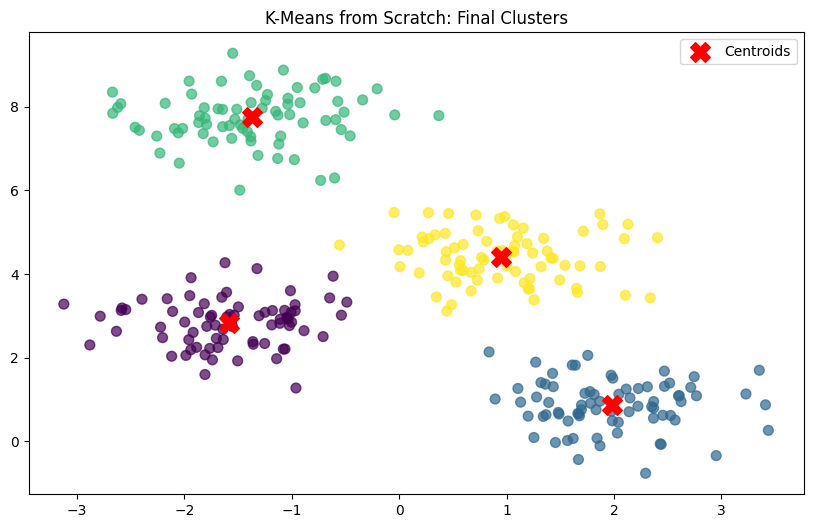

In [3]:
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=km.labels, s=50, cmap='viridis', alpha=0.7)
plt.scatter(km.centroids[:, 0], km.centroids[:, 1], s=200, c='red', marker='X', label='Centroids')
plt.title("K-Means from Scratch: Final Clusters")
plt.legend()
plt.show()

2D Visualization

In [4]:
import plotly.graph_objects as go

# Generate 3D blobs
X_3d, _ = make_blobs(n_samples=500, centers=3, n_features=3, cluster_std=0.8, random_state=42)
km_3d = KMeansScratch(k=3)
km_3d.fit(X_3d)

fig = go.Figure(data=[
    go.Scatter3d(x=X_3d[:,0], y=X_3d[:,1], z=X_3d[:,2], mode='markers',
                 marker=dict(size=3, color=km_3d.labels, colorscale='Viridis', opacity=0.6)),
    go.Scatter3d(x=km_3d.centroids[:,0], y=km_3d.centroids[:,1], z=km_3d.centroids[:,2],
                 mode='markers', marker=dict(size=10, color='red', symbol='x'), name='Centroids')
])

fig.update_layout(title="3D K-Means: Spatial Partitioning")
fig.show()

3D Visualization

Unlike supervised models, K-Means doesn't need to be "right" or "wrong" based on a label; it only cares about Internal Consistency—maximizing the similarity within a group while maximizing the distance between different groups. This is why scaling is so critical: because we use Euclidean distance, every dimension must have an equal "say" in the calculation. For your robotics projects, this is your go-to algorithm for Anomaly Detection; if a sensor reading falls too far from any known cluster centroid, your drone knows something is wrong.